In [1]:
# 신용 카드 고객 부도 예측 실습

In [2]:
try:
    import xlrd
except:
    %pip install xlrd
    # Successfully installed xlrd-2.0.2

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from pathlib import Path

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [8]:
try:
    from IPython.display import display
except:
    display = print

In [9]:
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False

In [10]:
file_path = Path('default of credit card clients.xls')
df = pd.read_excel(file_path, header=1)
print(df.shape)
display(df)

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [11]:
df = df.rename(columns={
    "default payment next month" : "default",
    "PAY_0" : "PAY_1"
})

In [12]:
if "ID" in df.columns:
    df = df.drop(columns="ID")
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_1      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   30000 non-nu

In [14]:
df.isnull().sum()

LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [15]:
df['default'].value_counts()

default
0    23364
1     6636
Name: count, dtype: int64

In [16]:
df['default'].value_counts(normalize=True)

default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

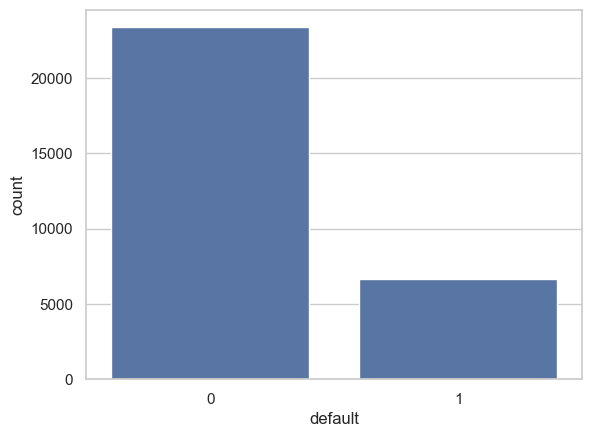

In [17]:
sns.countplot(data=df, x="default")
plt.show()

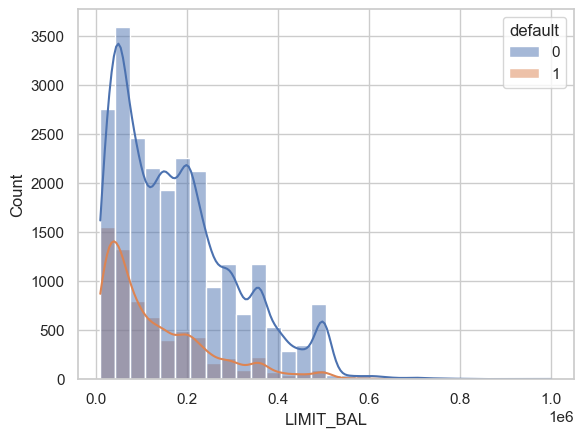

In [18]:
sns.histplot(data=df, x="LIMIT_BAL", hue="default", bins=30, kde=True)
plt.show()

In [19]:
pay_default = df.groupby("PAY_1")["default"].mean().reset_index()
pay_default

,PAY_1,default
0,-2,0.132294
1,-1,0.167781
2,0,0.128113
3,1,0.339479
4,2,0.691414
5,3,0.757764
6,4,0.684211
7,5,0.500000
8,6,0.545455
9,7,0.777778


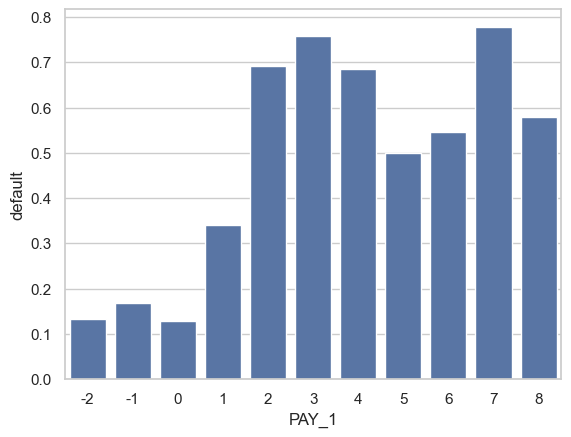

In [20]:
sns.barplot(data=pay_default, x="PAY_1", y="default", errorbar=None)
plt.show()

In [21]:
# 전처리

In [22]:
df['EDUCATION'] = df['EDUCATION'].replace({0:4, 5:4, 6:4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0:3})

In [23]:
X = df.drop(columns="default")
y = df['default']

In [24]:
# L1 리스트의 값들을 제곱한 값들을 L2 리스트 담는 과정 : for문
L1 = [ 1,2,3,4,5 ]
L2 = [] # 빈 리스트
for i in L1:
    # print(i) # 1,2,3,4,5
    # print(i ** 2) # 1,4,9,16,25
    L2.append( i ** 2 )
L2 # [1, 4, 9, 16, 25]

[1, 4, 9, 16, 25]

In [25]:
# L1 리스트의 값들을 제곱한 값들을 L3 리스트 담는 과정 : 리스트 표현식
L3 = [ i ** 2 for i in L1 ]
L3

[1, 4, 9, 16, 25]

In [26]:
cat_cols = [ "SEX", "EDUCATION", "MARRIAGE" ]
num_cols = [ col for col in X.columns if col not in cat_cols ] # 리스트 표현식

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
                                                   stratify=y)

In [28]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [29]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, class_weight="balanced",
                                              random_state=42),
    "Random Forest" : RandomForestClassifier(n_estimators=200, max_depth=8,
                                            min_samples_leaf=20, class_weight="balanced",
                                            random_state=42, n_jobs=-1)
}

Logistic Regression
              precision    recall  f1-score   support

           0     0.8685    0.6925    0.7706      4673
           1     0.3681    0.6307    0.4649      1327

    accuracy                         0.6788      6000
   macro avg     0.6183    0.6616    0.6177      6000
weighted avg     0.7578    0.6788    0.7030      6000



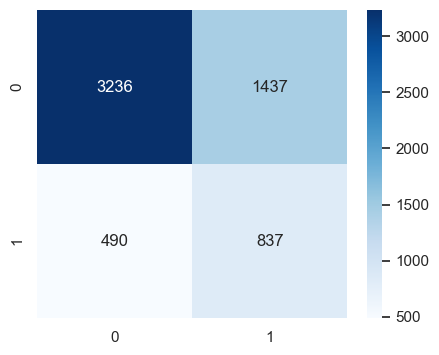

Random Forest
              precision    recall  f1-score   support

           0     0.8789    0.8279    0.8527      4673
           1     0.4969    0.5983    0.5429      1327

    accuracy                         0.7772      6000
   macro avg     0.6879    0.7131    0.6978      6000
weighted avg     0.7944    0.7772    0.7842      6000



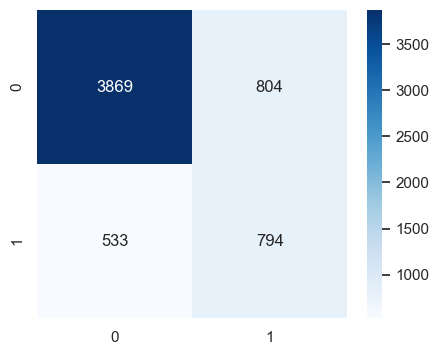

In [30]:
results = []
for name, model in models.items():
    # print(name, ":" , model) # Logistic Regression : LogisticRegression(...
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test) # O, X
    prob = pipe.predict_proba(X_test)[:, 1] # 확률
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, prob)
    })
    print(name)
    print(classification_report(y_test, pred, digits=4))
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues")
    plt.show()
    if name == "Random Forest":
        best_pipe = pipe

In [31]:
# ------------------------------------------------------------
# 7. 모델 성능 비교
# ------------------------------------------------------------
result_df = pd.DataFrame(results)
display(result_df.sort_values("roc_auc", ascending=False))

,model,accuracy,precision,recall,f1,roc_auc
1,Random Forest,0.777167,0.496871,0.598342,0.542906,0.773898
0,Logistic Regression,0.678833,0.368074,0.630746,0.464871,0.710365


In [32]:
# ------------------------------------------------------------
# 8. 변수 중요도 확인
# ------------------------------------------------------------
feature_names = best_pipe.named_steps["preprocess"].get_feature_names_out()
importances = best_pipe.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(importance_df.head(15))

,feature,importance
2,num__PAY_1,0.271293
3,num__PAY_2,0.141113
4,num__PAY_3,0.084525
5,num__PAY_4,0.072359
6,num__PAY_5,0.055849
0,num__LIMIT_BAL,0.045793
14,num__PAY_AMT1,0.045257
7,num__PAY_6,0.037821
15,num__PAY_AMT2,0.035764
16,num__PAY_AMT3,0.030131


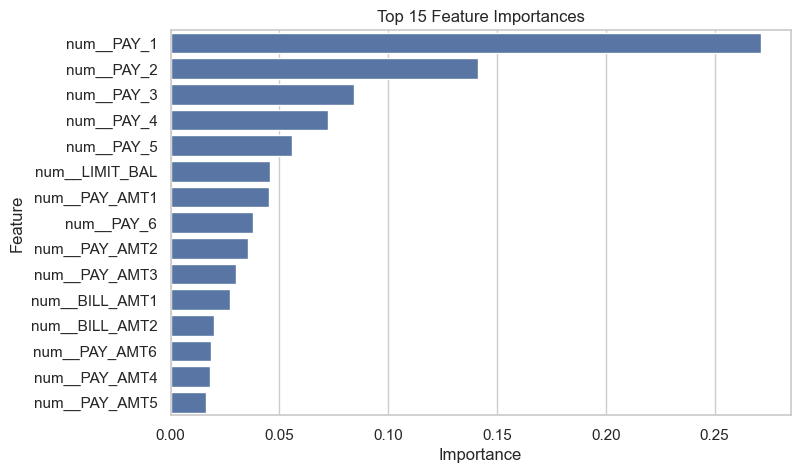

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance_df.head(15),
    x="importance",
    y="feature",
    errorbar=None
)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [34]:
# end